In [ ]:

import json
import logging
import re
from logging.handlers import RotatingFileHandler
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
N_SPLITS = 5
ROOT = Path(".")
DATA_DIR, ART_DIR, OUT_DIR, LOG_DIR = ROOT / "data", ROOT / "artifacts", ROOT / "outputs", ROOT / "logs"
for d in (OUT_DIR, LOG_DIR):
    d.mkdir(exist_ok=True)


def get_logger(name="shl"):
    logger = logging.getLogger(name)
    if logger.handlers:
        return logger
    logger.setLevel(logging.INFO)
    fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
    for h in (logging.StreamHandler(), RotatingFileHandler(LOG_DIR / "run.log", maxBytes=2_000_000, backupCount=3)):
        h.setFormatter(fmt)
        logger.addHandler(h)
    return logger


log = get_logger()


In [ ]:

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sub = pd.read_csv(DATA_DIR / "sample_submission.csv")
index = pd.concat([
    pd.DataFrame({"split": "train", "filename": train["filename"]}),
    pd.DataFrame({"split": "test", "filename": test["filename"]}),
], ignore_index=True)
saved_index = pd.read_csv(ART_DIR / "index.csv")
assert saved_index[["split", "filename"]].equals(index), "index.csv does not match the CSV row order"

n_train = len(train)
y = train["label"].to_numpy(dtype=float)
audio_emb = np.load(ART_DIR / "audio_emb.npy")
text_emb = np.load(ART_DIR / "text_emb.npy")
assert len(audio_emb) == len(text_emb) == len(index)
log.info("rows=%d (train=%d) audio_emb=%s text_emb=%s", len(index), n_train, audio_emb.shape, text_emb.shape)


2026-09-30 22:55:12,210 | INFO | rows=985 (train=769) audio_emb=(985, 1536) text_emb=(985, 768)


In [10]:
!pip install numpy pandas scipy scikit-learn matplotlib

  Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tensorflow-intel 2.16.1 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 7.35.1 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\ASHUTOSH\anaconda3\python.exe -m pip install --upgrade pip


In [ ]:
FILLERS = {"um", "umm", "uh", "uhh", "er", "erm", "ah", "hmm", "mm"}

recs = {}
with (ART_DIR / "transcripts.jsonl").open() as f:
    for line in f:
        r = json.loads(line)
        recs[(r["split"], r["filename"])] = r


def hand_features(r: dict) -> dict:
    """Length-robust features (rates, ratios) because test clips are shorter than train clips."""
    words = r["words"]
    toks = [t for t in (re.sub(r"[^a-z']", "", w[0].lower()) for w in words) if t]
    n = max(len(toks), 1)
    speech_min = max(r["duration_after_vad"], 1.0) / 60
    total_min = max(r["duration"], 1.0) / 60
    starts = np.array([w[1] for w in words]) if words else np.array([0.0])
    ends = np.array([w[2] for w in words]) if words else np.array([0.0])
    gaps = starts[1:] - ends[:-1] if len(words) > 1 else np.array([0.0])
    probs = np.array([w[3] for w in words]) if words else np.array([0.0])
    sents = [s for s in re.split(r"[.?!]+", r["text"]) if s.strip()]
    first100 = toks[:100]
    return {
        "no_speech_flag": float(len(toks) < 10),
        "wpm_total": len(toks) / total_min,
        "wpm_speech": len(toks) / speech_min,
        "speech_ratio": r["duration_after_vad"] / max(r["duration"], 1.0),
        "ttr100": len(set(first100)) / max(len(first100), 1),
        "filler_per100": 100 * sum(t in FILLERS for t in toks) / n,
        "repeat_per100": 100 * sum(a == b for a, b in zip(toks, toks[1:])) / n,
        "words_per_sentence": len(toks) / max(len(sents), 1),
        "mean_word_len": float(np.mean([len(t) for t in toks])) if toks else 0.0,
        "pause_gt05_per_min": float((gaps > 0.5).sum()) / speech_min,
        "pause_gt1_per_min": float((gaps > 1.0).sum()) / speech_min,
        "mean_gap": float(gaps.mean()),
        "max_gap": float(gaps.max()),
        "mean_word_prob": float(probs.mean()),
        "low_conf_frac": float((probs < 0.5).mean()),
        "avg_logprob": r["avg_logprob"],
        "max_no_speech_prob": r["max_no_speech_prob"],
    }


H = pd.DataFrame([hand_features(recs[(s, n)]) for s, n in zip(index["split"], index["filename"])])
cola_path = ART_DIR / "cola_feats.csv"
if cola_path.exists():
    H = pd.concat([H, pd.read_csv(cola_path)], axis=1)
log.info("handcrafted feature matrix %s", H.shape)

# interpretability: correlation of each handcrafted feature with the label (train rows only)
corr = H.iloc[:n_train].corrwith(pd.Series(y)).sort_values()
log.info("feature-label correlations:\n%s", corr.round(3).to_string())

2026-09-30 22:55:47,421 | INFO | handcrafted feature matrix (985, 20)
2026-09-30 22:55:47,450 | INFO | feature-label correlations:
low_conf_frac          -0.581
mean_gap               -0.203
max_gap                -0.197
repeat_per100          -0.110
pause_gt1_per_min      -0.107
words_per_sentence     -0.064
max_no_speech_prob     -0.021
pause_gt05_per_min     -0.017
filler_per100           0.039
speech_ratio            0.149
mean_word_len           0.178
wpm_speech              0.196
wpm_total               0.225
ttr100                  0.228
cola_min_p1             0.256
cola_frac_p1_gt_half    0.319
cola_mean_p1            0.368
avg_logprob             0.599
mean_word_prob          0.667
no_speech_flag            NaN


In [ ]:

strat = (np.where((y > 0) & (y < 2), 2.0, y) * 2).astype(int)
folds = list(StratifiedKFold(N_SPLITS, shuffle=True, random_state=SEED).split(np.zeros(n_train), strat))


def metrics(name, y_true, y_pred):
    p = np.clip(y_pred, 0, 5)
    return {"model": name,
            "rmse": float(np.sqrt(np.mean((y_true - p) ** 2))),
            "pearson": float(pearsonr(y_true, p)[0]),
            "spearman": float(spearmanr(y_true, p)[0])}


def make_ridge():
    return make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(0, 5, 15)))


def make_hgb():
    return HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=300,
                                         l2_regularization=1.0, random_state=SEED)


def run_cv(name, make_model, X_all):
    """Out-of-fold preds on train, fold-averaged preds on test, plus an all-train fit for train RMSE."""
    X, X_test = X_all[:n_train], X_all[n_train:]
    oof, test_pred = np.zeros(n_train), np.zeros(len(X_test))
    for tr_idx, va_idx in folds:
        m = make_model().fit(X[tr_idx], y[tr_idx])
        oof[va_idx] = m.predict(X[va_idx])
        test_pred += m.predict(X_test) / len(folds)
    train_pred = make_model().fit(X, y).predict(X)
    log.info("%-14s OOF %s", name, {k: round(v, 4) for k, v in metrics(name, y, oof).items() if k != "model"})
    return {"oof": oof, "test": test_pred, "train": train_pred}


In [12]:

# %% Cell 5: base models
feature_sets = {
    "ridge_audio": (make_ridge, audio_emb),
    "ridge_text": (make_ridge, text_emb),
    "hgb_handcrafted": (make_hgb, H.to_numpy(dtype=float)),
}
results = {name: run_cv(name, mk, X) for name, (mk, X) in feature_sets.items()}


2026-09-30 23:02:13,343 | INFO | ridge_audio    OOF {'rmse': 0.578, 'pearson': 0.8847, 'spearman': 0.8303}
2026-09-30 23:02:16,597 | INFO | ridge_text     OOF {'rmse': 1.0297, 'pearson': 0.5564, 'spearman': 0.619}
c:\Users\ASHUTOSH\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\ASHUTOSH\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\ASHUTOSH\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs)

In [21]:
H.to_csv("artifacts/handcrafted.csv", index=False)

In [ ]:
P_oof = np.column_stack([r["oof"] for r in results.values()])
P_train = np.column_stack([r["train"] for r in results.values()])
P_test = np.column_stack([r["test"] for r in results.values()])
blender = LinearRegression(positive=True).fit(P_oof, y)
log.info("blend weights=%s intercept=%.3f", dict(zip(results, blender.coef_.round(3))), blender.intercept_)

blend_oof = np.clip(blender.predict(P_oof), 0, 5)
blend_train = np.clip(blender.predict(P_train), 0, 5)
blend_test = np.clip(blender.predict(P_test), 0, 5)

rows = [metrics(f"{n} (OOF)", y, r["oof"]) for n, r in results.items()]
rows += [metrics("BLEND (OOF, honest estimate)", y, blend_oof),
         metrics("BLEND (TRAIN, in-sample)", y, blend_train)]
table = pd.DataFrame(rows).round(4)
table.to_csv(OUT_DIR / "metrics.csv", index=False)
log.info("\n%s", table.to_string(index=False))
log.info("REQUIRED BY SHL - training RMSE (in-sample): %.4f | out-of-fold RMSE: %.4f",
         table.iloc[-1]["rmse"], table.iloc[-2]["rmse"])

2026-09-30 23:05:55,694 | INFO | blend weights={'ridge_audio': 0.803, 'ridge_text': 0.162, 'hgb_handcrafted': 0.214} intercept=-0.588
2026-09-30 23:05:55,738 | INFO | 
                       model   rmse  pearson  spearman
           ridge_audio (OOF) 0.5780   0.8847    0.8303
            ridge_text (OOF) 1.0297   0.5564    0.6190
       hgb_handcrafted (OOF) 0.8335   0.7408    0.7014
BLEND (OOF, honest estimate) 0.5447   0.8983    0.8550
    BLEND (TRAIN, in-sample) 0.3532   0.9590    0.9417
2026-09-30 23:05:55,739 | INFO | REQUIRED BY SHL - training RMSE (in-sample): 0.3532 | out-of-fold RMSE: 0.5447


In [14]:
mask = y > 0
for n, r in results.items():
    print(n, {k: round(v, 3) for k, v in metrics(n, y[mask], r["oof"][mask]).items() if k != "model"})
print("BLEND", {k: round(v, 3) for k, v in metrics("blend", y[mask], blend_oof[mask]).items() if k != "model"})

ridge_audio {'rmse': 0.591, 'pearson': 0.813, 'spearman': 0.803}
ridge_text {'rmse': 0.805, 'pearson': 0.628, 'spearman': 0.641}
hgb_handcrafted {'rmse': 0.779, 'pearson': 0.659, 'spearman': 0.669}
BLEND {'rmse': 0.553, 'pearson': 0.838, 'spearman': 0.832}


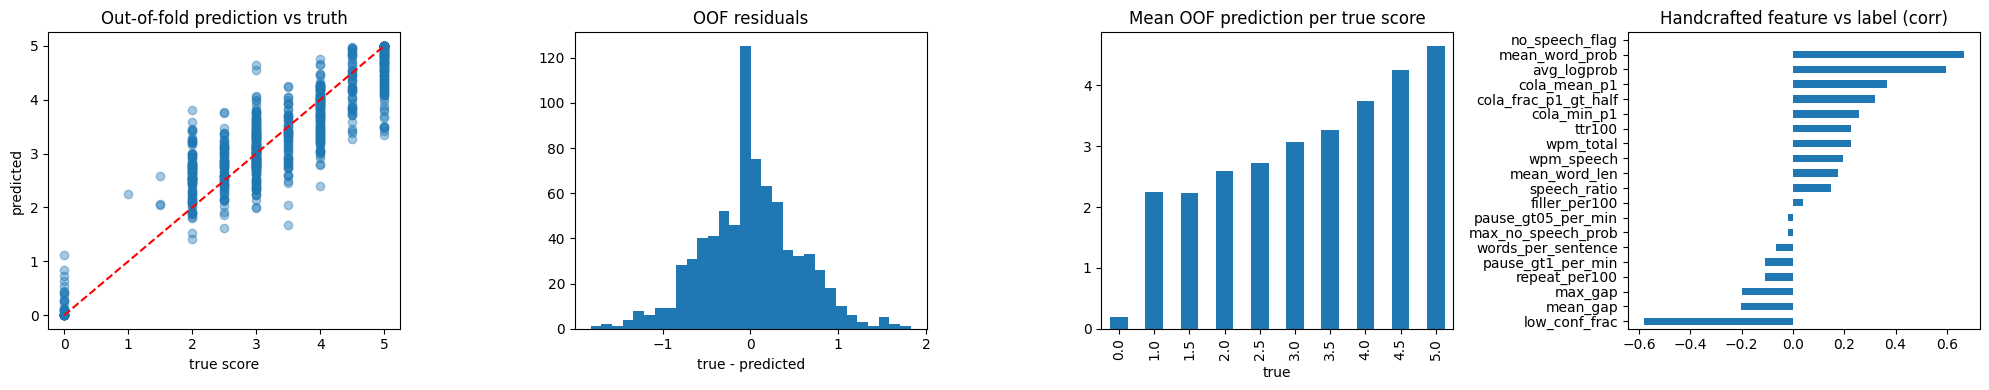

In [ ]:

fig, ax = plt.subplots(1, 4, figsize=(20, 4))
ax[0].scatter(y, blend_oof, alpha=0.4)
ax[0].plot([0, 5], [0, 5], "r--")
ax[0].set(title="Out-of-fold prediction vs truth", xlabel="true score", ylabel="predicted")
ax[1].hist(y - blend_oof, bins=30)
ax[1].set(title="OOF residuals", xlabel="true - predicted")
pd.DataFrame({"true": y, "pred": blend_oof}).groupby("true")["pred"].mean().plot.bar(ax=ax[2], title="Mean OOF prediction per true score")
corr.plot.barh(ax=ax[3], title="Handcrafted feature vs label (corr)")
plt.tight_layout()
plt.savefig(OUT_DIR / "report_plots.png", dpi=120)
plt.show()


In [ ]:

sub_a = pd.DataFrame({"filename": test["filename"], "label": blend_test})
sub_a.to_csv(OUT_DIR / "submission_test_ids.csv", index=False)

lookup = dict(zip(test["filename"], blend_test))
overlap = sum(f in lookup for f in sub["filename"])
sub_b = pd.DataFrame({"filename": sub["filename"],
                      "label": [lookup.get(f, float(y.mean())) for f in sub["filename"]]})
sub_b.to_csv(OUT_DIR / "submission_samplefmt_ids.csv", index=False)
log.info("submissions written | sample_submission ids matched to test.csv: %d/%d", overlap, len(sub))

2026-09-30 23:06:20,299 | INFO | submissions written | sample_submission ids matched to test.csv: 25/204


In [ ]:

import json
import logging
import os
from logging.handlers import RotatingFileHandler
from pathlib import Path

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")  # silences the Windows core-count warning

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

SEED, N_SPLITS = 42, 5
TOP_K_LAYERS = 2                
EXCLUDE_ZERO_FROM_TRAINING = True   

ROOT = Path(".")
DATA_DIR, ART_DIR, OUT_DIR, LOG_DIR = ROOT / "data", ROOT / "artifacts", ROOT / "outputs", ROOT / "logs"
for d in (OUT_DIR, LOG_DIR):
    d.mkdir(exist_ok=True)


def get_logger(name="shl"):
    logger = logging.getLogger(name)
    if logger.handlers:
        return logger
    logger.setLevel(logging.INFO)
    fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
    for h in (logging.StreamHandler(), RotatingFileHandler(LOG_DIR / "run_v2.log", maxBytes=2_000_000, backupCount=3)):
        h.setFormatter(fmt)
        logger.addHandler(h)
    return logger


log = get_logger()

In [ ]:

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
index = pd.concat([
    pd.DataFrame({"split": "train", "filename": train["filename"]}),
    pd.DataFrame({"split": "test", "filename": test["filename"]}),
], ignore_index=True)
assert pd.read_csv(ART_DIR / "index.csv")[["split", "filename"]].equals(index), "row order mismatch"

n_train = len(train)
y = train["label"].to_numpy(dtype=float)
text_emb = np.load(ART_DIR / "text_emb.npy")
H = pd.read_csv(ART_DIR / "handcrafted.csv").to_numpy(dtype=float)
wavlm = np.load(ART_DIR / "wavlm_layers.npy")      # (985, 13, 768)
whisper = np.load(ART_DIR / "whisper_layers.npy")  # (985, 7, 1280)
w_layer_ids = json.loads((ART_DIR / "whisper_layers.json").read_text())
assert len(wavlm) == len(whisper) == len(text_emb) == len(H) == len(index)
log.info("wavlm %s whisper %s text %s handcrafted %s", wavlm.shape, whisper.shape, text_emb.shape, H.shape)

2026-10-01 10:37:44,303 | INFO | wavlm (985, 13, 768) whisper (985, 7, 1280) text (985, 768) handcrafted (985, 20)


In [ ]:

strat = (np.where((y > 0) & (y < 2), 2.0, y) * 2).astype(int)
folds = list(StratifiedKFold(N_SPLITS, shuffle=True, random_state=SEED).split(np.zeros(n_train), strat))
nonzero = y > 0


def metrics(name, y_true, y_pred):
    p = np.clip(y_pred, 0, 5)
    return {"model": name, "rmse": float(np.sqrt(np.mean((y_true - p) ** 2))),
            "pearson": float(pearsonr(y_true, p)[0]), "spearman": float(spearmanr(y_true, p)[0])}


def make_ridge():
    return make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(0, 5, 15)))


def make_svr():
    return make_pipeline(StandardScaler(), SVR(kernel="rbf", C=3.0, epsilon=0.1, gamma="scale"))


def make_hgb():
    return HistGradientBoostingRegressor(max_depth=3, learning_rate=0.05, max_iter=300,
                                         l2_regularization=1.0, random_state=SEED)


def run_cv(name, make_model, X_all):
    """OOF preds on train, fold-averaged test preds, and an all-train fit for the train RMSE."""
    X, X_test = X_all[:n_train], X_all[n_train:]
    oof, test_pred = np.zeros(n_train), np.zeros(len(X_test))
    for tr_idx, va_idx in folds:
        if EXCLUDE_ZERO_FROM_TRAINING:
            tr_idx = tr_idx[nonzero[tr_idx]]
        m = make_model().fit(X[tr_idx], y[tr_idx])
        oof[va_idx] = m.predict(X[va_idx])
        test_pred += m.predict(X_test) / len(folds)
    fit_idx = np.where(nonzero)[0] if EXCLUDE_ZERO_FROM_TRAINING else np.arange(n_train)
    train_pred = make_model().fit(X[fit_idx], y[fit_idx]).predict(X)
    a, b = metrics(name, y, oof), metrics(name, y[nonzero], oof[nonzero])
    log.info("%-18s all: rmse=%.4f r=%.4f | non-zero: rmse=%.4f r=%.4f",
             name, a["rmse"], a["pearson"], b["rmse"], b["pearson"])
    return {"oof": oof, "test": test_pred, "train": train_pred}


2026-10-01 10:38:20,372 | INFO | layer scan (RMSE/Pearson on non-zero rows):
 source  layer   rmse  pearson
  wavlm      0 0.7978   0.6298
  wavlm      1 0.7511   0.6758
  wavlm      2 0.6988   0.7286
  wavlm      3 0.6743   0.7472
  wavlm      4 0.6514   0.7664
  wavlm      5 0.6310   0.7828
  wavlm      6 0.6164   0.7943
  wavlm      7 0.5867   0.8159
  wavlm      8 0.5811   0.8199
  wavlm      9 0.5844   0.8176
  wavlm     10 0.5771   0.8230
  wavlm     11 0.5820   0.8194
  wavlm     12 0.5993   0.8067
whisper      8 0.6689   0.7515
whisper     12 0.6429   0.7733
whisper     16 0.6319   0.7820
whisper     20 0.5771   0.8224
whisper     24 0.5742   0.8242
whisper     28 0.5601   0.8339
whisper     32 0.5439   0.8451


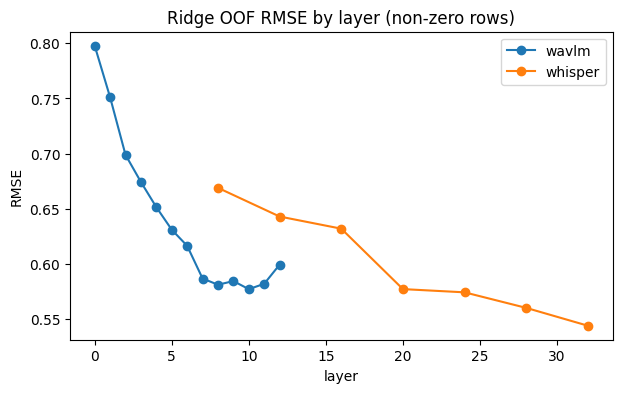

2026-10-01 10:38:20,863 | INFO | best layers (array indices): {'wavlm': [10, 8], 'whisper': [6, 5]}


In [ ]:

def scan(arr, name, layer_ids):
    rows = []
    for i, lid in enumerate(layer_ids):
        X = arr[:n_train, i, :]
        oof = np.zeros(n_train)
        for tr_idx, va_idx in folds:
            if EXCLUDE_ZERO_FROM_TRAINING:
                tr_idx = tr_idx[nonzero[tr_idx]]
            oof[va_idx] = make_ridge().fit(X[tr_idx], y[tr_idx]).predict(X[va_idx])
        rows.append({"source": name, "array_idx": i, "layer": lid, **metrics(f"{name}_L{lid}", y[nonzero], oof[nonzero])})
    return pd.DataFrame(rows)


scan_df = pd.concat([scan(wavlm, "wavlm", list(range(wavlm.shape[1]))),
                     scan(whisper, "whisper", w_layer_ids)], ignore_index=True)
scan_df.drop(columns="model").round(4).to_csv(OUT_DIR / "layer_scan.csv", index=False)
log.info("layer scan (RMSE/Pearson on non-zero rows):\n%s",
         scan_df[["source", "layer", "rmse", "pearson"]].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
for src, g in scan_df.groupby("source"):
    ax.plot(g["layer"], g["rmse"], marker="o", label=src)
ax.set(title="Ridge OOF RMSE by layer (non-zero rows)", xlabel="layer", ylabel="RMSE")
ax.legend()
plt.savefig(OUT_DIR / "layer_scan.png", dpi=120)
plt.show()

best = {src: g.sort_values("rmse")["array_idx"].head(TOP_K_LAYERS).tolist() for src, g in scan_df.groupby("source")}
log.info("best layers (array indices): %s", best)
wavlm_X = np.concatenate([wavlm[:, i, :] for i in best["wavlm"]], axis=1)
whisper_X = np.concatenate([whisper[:, i, :] for i in best["whisper"]], axis=1)


In [38]:
for C in (1, 3, 10, 30):
    for eps in (0.05, 0.1, 0.2):
        oof = np.zeros(n_train)
        for tr_idx, va_idx in folds:
            X = whisper_X[:n_train]
            m = make_pipeline(StandardScaler(), SVR(C=C, epsilon=eps)).fit(X[tr_idx], y[tr_idx])
            oof[va_idx] = m.predict(X[va_idx])
        print(C, eps, round(metrics("x", y, oof)["rmse"], 4))

1 0.05 0.5561
1 0.1 0.5565
1 0.2 0.5607
3 0.05 0.5333
3 0.1 0.5349
3 0.2 0.5404
10 0.05 0.5322
10 0.1 0.534
10 0.2 0.54
30 0.05 0.5322
30 0.1 0.534
30 0.2 0.54


In [ ]:

feature_sets = {
    "ridge_wavlm": (make_ridge, wavlm_X),
    "svr_wavlm": (make_svr, wavlm_X),
    "ridge_whisper": (make_ridge, whisper_X),
    "svr_whisper": (make_svr, whisper_X),
    "ridge_text": (make_ridge, text_emb),
    "hgb_handcrafted": (make_hgb, H),
}
results = {name: run_cv(name, mk, X) for name, (mk, X) in feature_sets.items()}


2026-10-01 10:38:23,581 | INFO | ridge_wavlm        all: rmse=0.7457 r=0.8099 | non-zero: rmse=0.5628 r=0.8322
2026-10-01 10:38:27,784 | INFO | svr_wavlm          all: rmse=0.8483 r=0.7462 | non-zero: rmse=0.5475 r=0.8440
2026-10-01 10:38:30,493 | INFO | ridge_whisper      all: rmse=0.7868 r=0.7859 | non-zero: rmse=0.5401 r=0.8468
2026-10-01 10:38:37,557 | INFO | svr_whisper        all: rmse=0.8507 r=0.7411 | non-zero: rmse=0.5172 r=0.8618
2026-10-01 10:38:39,788 | INFO | ridge_text         all: rmse=1.0389 r=0.5600 | non-zero: rmse=0.7577 r=0.6646
2026-10-01 10:38:42,372 | INFO | hgb_handcrafted    all: rmse=0.9472 r=0.6541 | non-zero: rmse=0.7534 r=0.6718


In [ ]:

P_oof = np.column_stack([r["oof"] for r in results.values()])
P_train = np.column_stack([r["train"] for r in results.values()])
P_test = np.column_stack([r["test"] for r in results.values()])
fit_rows = nonzero if EXCLUDE_ZERO_FROM_TRAINING else np.ones(n_train, dtype=bool)
blender = LinearRegression(positive=True).fit(P_oof[fit_rows], y[fit_rows])
log.info("blend weights=%s intercept=%.3f", dict(zip(results, blender.coef_.round(3))), blender.intercept_)

blend_oof = np.clip(blender.predict(P_oof), 0, 5)
blend_train = np.clip(blender.predict(P_train), 0, 5)
blend_test = np.clip(blender.predict(P_test), 0, 5)

rows = []
for n, r in results.items():
    rows += [metrics(f"{n} (OOF, all)", y, r["oof"]), metrics(f"{n} (OOF, non-zero)", y[nonzero], r["oof"][nonzero])]
rows += [metrics("BLEND (OOF, all)", y, blend_oof),
         metrics("BLEND (OOF, non-zero)", y[nonzero], blend_oof[nonzero]),
         metrics("BLEND (TRAIN, in-sample)", y, blend_train)]
table = pd.DataFrame(rows).round(4)
table.to_csv(OUT_DIR / "metrics_v2_all.csv", index=False)
log.info("exclude_zero=%s\n%s", EXCLUDE_ZERO_FROM_TRAINING, table.to_string(index=False))
log.info("REQUIRED BY SHL - training RMSE (in-sample): %.4f | out-of-fold RMSE (all rows): %.4f",
         table.iloc[-1]["rmse"], table.iloc[-3]["rmse"])


2026-10-01 10:38:42,407 | INFO | blend weights={'ridge_wavlm': 0.146, 'svr_wavlm': 0.198, 'ridge_whisper': 0.055, 'svr_whisper': 0.555, 'ridge_text': 0.114, 'hgb_handcrafted': 0.086} intercept=-0.535
2026-10-01 10:38:42,473 | INFO | exclude_zero=True
                          model   rmse  pearson  spearman
         ridge_wavlm (OOF, all) 0.7457   0.8099    0.8348
    ridge_wavlm (OOF, non-zero) 0.5628   0.8322    0.8252
           svr_wavlm (OOF, all) 0.8483   0.7462    0.8091
      svr_wavlm (OOF, non-zero) 0.5475   0.8440    0.8334
       ridge_whisper (OOF, all) 0.7868   0.7859    0.8320
  ridge_whisper (OOF, non-zero) 0.5401   0.8468    0.8395
         svr_whisper (OOF, all) 0.8507   0.7411    0.8090
    svr_whisper (OOF, non-zero) 0.5172   0.8618    0.8511
          ridge_text (OOF, all) 1.0389   0.5600    0.6346
     ridge_text (OOF, non-zero) 0.7577   0.6646    0.6699
     hgb_handcrafted (OOF, all) 0.9472   0.6541    0.6743
hgb_handcrafted (OOF, non-zero) 0.7534   0.6718    0.

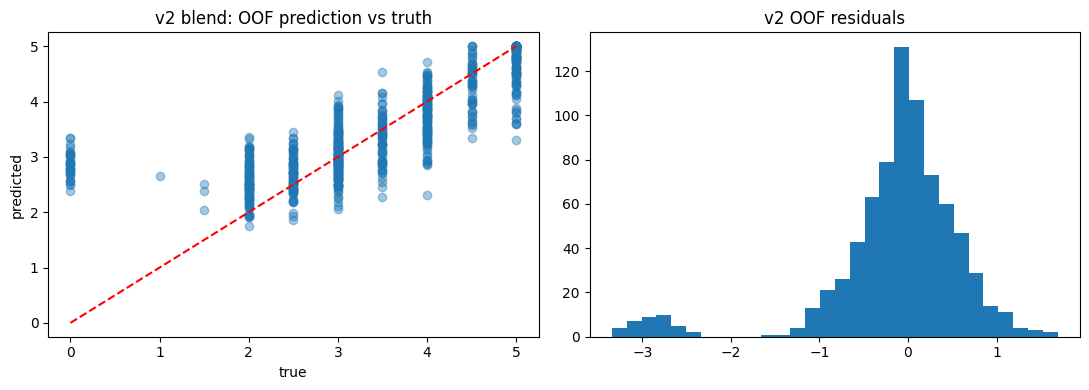

2026-10-01 10:38:43,991 | INFO | wrote outputs/submission_v2_nozero_test_ids.csv


In [ ]:

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(y, blend_oof, alpha=0.4)
ax[0].plot([0, 5], [0, 5], "r--")
ax[0].set(title="v2 blend: OOF prediction vs truth", xlabel="true", ylabel="predicted")
ax[1].hist(y - blend_oof, bins=30)
ax[1].set(title="v2 OOF residuals")
plt.tight_layout()
plt.savefig(OUT_DIR / "report_plots_v2.png", dpi=120)
plt.show()

tag = "nozero" if EXCLUDE_ZERO_FROM_TRAINING else "all"
pd.DataFrame({"filename": test["filename"], "label": blend_test}).to_csv(
    OUT_DIR / f"submission_v2_{tag}_test_ids.csv", index=False)
log.info("wrote outputs/submission_v2_%s_test_ids.csv", tag)